# Attention to the previous newline by layer and head

For each transformer layer, this notebook plots the average attention paid by every head to the most recent preceding `_NEWLINE_` token as a function of token position within the current line.

Position 0 is the first content token after a newline. Queries before the first actual newline and newline queries themselves are excluded. As in the reference figure, every head's average-attention curve is independently normalized by its maximum, making the shapes and preferred positional offsets easy to compare.

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"

N_SEQUENCES = 5_000
COLLECTION_BATCH_SIZE = 256
DATA_SEED = 27_071
NORMALIZE_EACH_HEAD = True

# Optionally set this to an integer to draw a dotted vertical reference line,
# analogous to the "Sink Size" marker in the supplied figure.
REFERENCE_POSITION = None

In [7]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH,
    model=model,
    map_location=device,
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
seq_len = cfg["task"]["seq_len"]

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Model has {n_layers} layers and {n_heads} heads per layer")

Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Model has 3 layers and 4 heads per layer


## Collect and aggregate attention patterns

TransformerLens attention patterns have shape `[batch, head, query_position, key_position]`. For each valid query, the code finds the key position of its most recent preceding newline and accumulates that one attention value for every layer and head.

In [8]:
def previous_newline_metadata(token_rows: torch.Tensor) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return batch indices, query indices, and within-line offsets.

    Only queries with an actual preceding _NEWLINE_ are returned. Position 0 is
    the first token after that newline.
    """
    batch_indices = []
    query_indices = []
    offsets = []

    for batch_index, token_row in enumerate(token_rows.detach().cpu().tolist()):
        previous_newline_position = None

        for query_position, token_id in enumerate(token_row):
            if token_id == vocab.newline_id:
                previous_newline_position = query_position
                continue

            if previous_newline_position is not None:
                batch_indices.append(batch_index)
                query_indices.append(query_position)
                offsets.append(query_position - previous_newline_position - 1)

    return (
        np.asarray(batch_indices, dtype=np.int64),
        np.asarray(query_indices, dtype=np.int64),
        np.asarray(offsets, dtype=np.int64),
    )


@torch.no_grad()
def collect_attention_to_previous_newline(
    n_sequences: int,
    *,
    batch_size: int = COLLECTION_BATCH_SIZE,
    seed: int = DATA_SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Aggregate attention to the previous newline by layer, head, and offset."""
    attention_sums = np.zeros((n_layers, n_heads, seq_len), dtype=np.float64)
    examples_per_offset = np.zeros(seq_len, dtype=np.int64)
    pattern_names = [
        f"blocks.{layer}.attn.hook_pattern"
        for layer in range(n_layers)
    ]

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )

        batch_indices, query_indices, offsets = previous_newline_metadata(batch.tokens)
        if len(offsets) == 0:
            continue

        # The key for each valid query is determined by its offset:
        # key = query - offset - 1.
        key_indices = query_indices - offsets - 1

        _, cache = model.run_with_cache(
            batch.tokens,
            prepend_bos=False,
            names_filter=lambda name: name in pattern_names,
        )

        np.add.at(examples_per_offset, offsets, 1)

        for layer, pattern_name in enumerate(pattern_names):
            # [batch, head, query, key] -> [valid_query, head]
            pattern = cache[pattern_name].detach().cpu().numpy()
            selected_attention = pattern[
                batch_indices,
                :,
                query_indices,
                key_indices,
            ]

            for head in range(n_heads):
                np.add.at(
                    attention_sums[layer, head],
                    offsets,
                    selected_attention[:, head],
                )

    observed_offsets = examples_per_offset > 0
    mean_attention = np.full_like(attention_sums, np.nan)
    mean_attention[:, :, observed_offsets] = (
        attention_sums[:, :, observed_offsets]
        / examples_per_offset[observed_offsets][None, None, :]
    )
    return mean_attention, examples_per_offset

In [9]:
mean_attention_to_newline, examples_per_offset = collect_attention_to_previous_newline(
    N_SEQUENCES
)

observed_positions = np.flatnonzero(examples_per_offset > 0)
if len(observed_positions) == 0:
    raise RuntimeError("No tokens with a preceding newline were found.")

last_observed_position = int(observed_positions[-1])
positions = np.arange(last_observed_position + 1)
curves = mean_attention_to_newline[:, :, : last_observed_position + 1].copy()

if NORMALIZE_EACH_HEAD:
    head_maxima = np.nanmax(curves, axis=2, keepdims=True)
    curves = curves / np.maximum(head_maxima, 1e-12)

print(f"Observed within-line positions: 0 through {last_observed_position}")
print(f"Valid query tokens: {examples_per_offset.sum():,}")
print("Queries at each of the first ten positions:", examples_per_offset[:10])

Observed within-line positions: 0 through 31
Valid query tokens: 619,160
Queries at each of the first ten positions: [39759 39499 39241 38970 38721 38464 38190 37928 37564 36998]


## One figure per layer

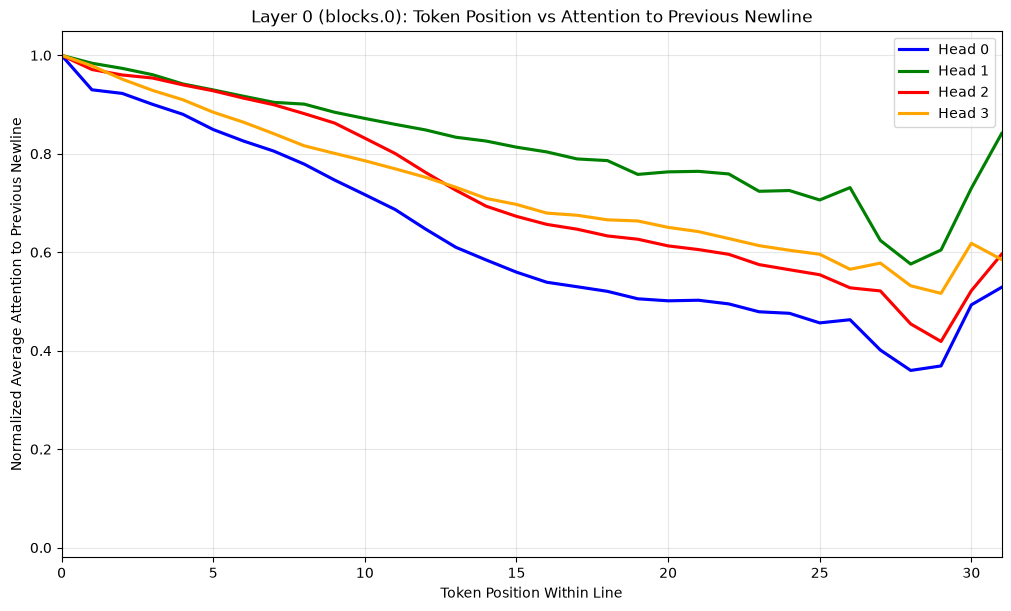

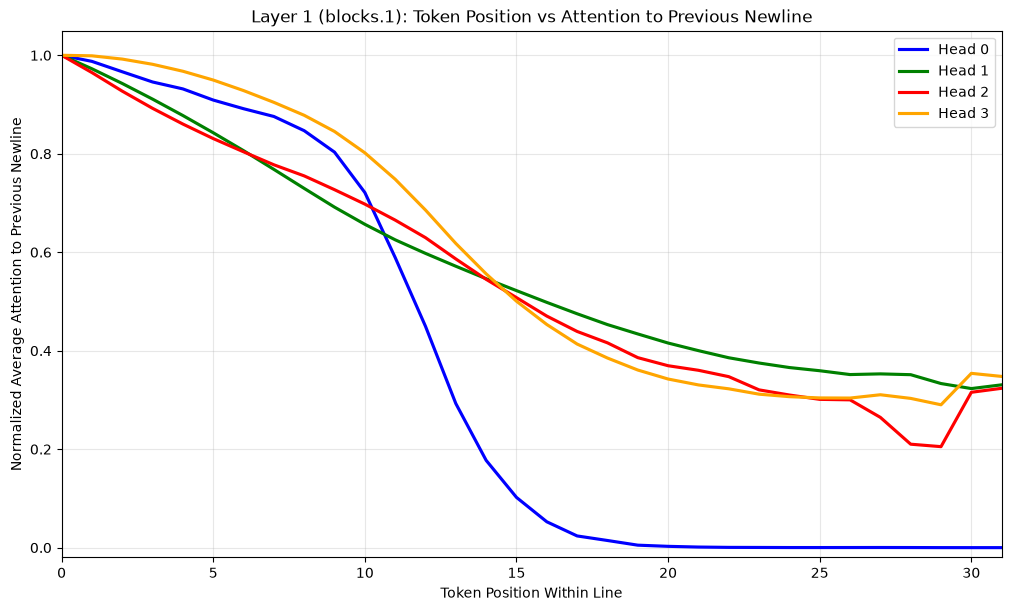

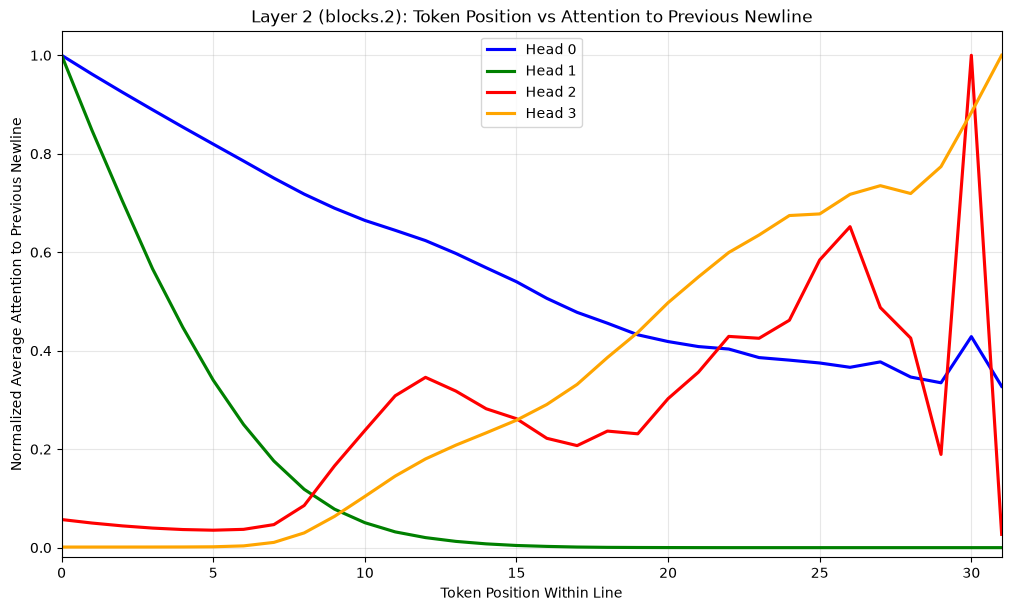

In [10]:
# Match the supplied figure's colors when the model has four heads.
reference_colors = ["blue", "green", "red", "orange"]
head_colors = (
    reference_colors
    if n_heads == 4
    else [plt.get_cmap("tab10")(head / max(n_heads - 1, 1)) for head in range(n_heads)]
)

for layer in range(n_layers):
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    for head in range(n_heads):
        ax.plot(
            positions,
            curves[layer, head],
            color=head_colors[head],
            linewidth=2.25,
            label=f"Head {head}",
        )

    if REFERENCE_POSITION is not None:
        ax.axvline(
            REFERENCE_POSITION,
            color="red",
            linestyle=":",
            linewidth=1.5,
        )
        ax.text(
            REFERENCE_POSITION + 0.15,
            0.95,
            "Reference\nPosition",
            color="red",
            va="top",
        )

    ax.set_xlim(0, last_observed_position)
    if NORMALIZE_EACH_HEAD:
        ax.set_ylim(-0.02, 1.05)
        ax.set_ylabel("Normalized Average Attention to Previous Newline")
    else:
        ax.set_ylim(bottom=0)
        ax.set_ylabel("Average Attention to Previous Newline")

    ax.set_xlabel("Token Position Within Line")
    ax.set_title(
        f"Layer {layer} (blocks.{layer}): Token Position vs Attention to Previous Newline"
    )
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.show()